In [1]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 1 · SETUP E IMPORTS
# ══════════════════════════════════════════════════════════════════
#
# Esta célula configura o ambiente para o experimento de subsampling.
#
# ARQUIVOS NECESSÁRIOS NO /content/:
#   ├── compas_prepared.csv     → dataset final pré-processado
#   ├── lr_model.pkl            → modelo Logistic Regression tunado
#   ├── lr_scaler.pkl           → StandardScaler ajustado para a LR
#   └── xgb_model.pkl           → modelo XGBoost tunado
#
# Os modelos baseline servem APENAS como referência de hiperparâmetros.
# Cada nível de subsampling retreina novos modelos do zero.
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

from google.colab import files
import io

uploaded = files.upload()

Saving xgb_model.pkl to xgb_model.pkl
Saving xgb_results.csv to xgb_results.csv
Saving lr_model.pkl to lr_model.pkl
Saving lr_scaler.pkl to lr_scaler.pkl
Saving lr_results.csv to lr_results.csv
Saving compas_prepared.csv to compas_prepared.csv


In [2]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 2 · CARGA DE DADOS E MODELOS BASELINE
# ══════════════════════════════════════════════════════════════════
#
# Carrega:
#   1. Dataset preparado (compas_prepared.csv)
#   2. Modelos baseline (apenas para extrair hiperparâmetros tunados)
#
# Os hiperparâmetros tunados serão reutilizados em cada subsampling
# para manter consistência metodológica — o que muda entre execuções
# é apenas a composição do conjunto de TREINO.
# ══════════════════════════════════════════════════════════════════

df = pd.read_csv('/content/compas_prepared.csv')

with open('/content/lr_model.pkl', 'rb') as f:
    lr_baseline = pickle.load(f)
with open('/content/xgb_model.pkl', 'rb') as f:
    xgb_baseline = pickle.load(f)

# Hiperparâmetros tunados extraídos dos baselines
LR_PARAMS  = lr_baseline.get_params()
XGB_PARAMS = xgb_baseline.get_params()

print(f"Dataset shape: {df.shape}")
print(f"\nDistribuição racial original:")
print(df['race'].value_counts())
print(f"\nProporção:")
print(df['race'].value_counts(normalize=True).mul(100).round(2))

Dataset shape: (4610, 13)

Distribuição racial original:
race
African-American    2732
Caucasian           1878
Name: count, dtype: int64

Proporção:
race
African-American    59.26
Caucasian           40.74
Name: proportion, dtype: float64


In [3]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 3 · DEFINIÇÃO DO CONJUNTO DE TESTE FIXO
# ══════════════════════════════════════════════════════════════════
#
# DECISÃO METODOLÓGICA CRÍTICA:
# O conjunto de teste é mantido FIXO em todas as execuções, com a
# distribuição racial original do dataset. Apenas o conjunto de
# TREINO sofre subsampling.
#
# Justificativa: queremos medir como modelos treinados em dados
# enviesados se comportam ao classificar a população real (com
# diversidade racial completa). Subamostrar o teste mascararia
# esse efeito.
#
# O split usa o mesmo random_state (42) dos modelos baseline para
# garantir comparabilidade direta.
# ══════════════════════════════════════════════════════════════════

FEATURES = [
    'sex_encoded', 'age_cat_encoded', 'race_encoded',
    'juv_fel_count', 'juv_misd_count', 'juv_other_count',
    'priors_count', 'c_charge_degree_encoded',
]
NUMERIC_FEATURES = ['juv_fel_count', 'juv_misd_count',
                    'juv_other_count', 'priors_count']
TARGET = 'two_year_recid'

X     = df[FEATURES]
y     = df[TARGET]
race  = df['race']

# Split fixo — teste será reutilizado em todas as execuções
X_train_full, X_test, y_train_full, y_test, race_train_full, race_test = train_test_split(
    X, y, race,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Treino completo: {X_train_full.shape}")
print(f"Teste fixo:      {X_test.shape}")
print(f"\nDistribuição racial — TESTE (fixa em todas execuções):")
print(race_test.value_counts())

Treino completo: (3688, 8)
Teste fixo:      (922, 8)

Distribuição racial — TESTE (fixa em todas execuções):
race
African-American    553
Caucasian           369
Name: count, dtype: int64


In [4]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 4 · FUNÇÃO DE SUBSAMPLING
# ══════════════════════════════════════════════════════════════════
#
# Reduz progressivamente a proporção de African-Americans no
# conjunto de treino, mantendo Caucasians integralmente.
#
# Parâmetros:
#   - level (float): fração de AA a manter (1.00, 0.75, 0.50, 0.25,
#                    0.10, 0.05)
#   - seed (int): controla a aleatoriedade da amostragem para
#                 permitir múltiplas execuções com seeds distintas
#
# Retorna:
#   - X_train_sub, y_train_sub, race_train_sub
# ══════════════════════════════════════════════════════════════════

def subsample_training(X_train, y_train, race_train, level, seed):
    """Subamostra African-Americans no treino, mantendo Caucasians."""

    aa_mask = (race_train == 'African-American')
    w_mask  = (race_train == 'Caucasian')

    # Índices dos African-Americans a manter
    aa_indices = race_train[aa_mask].index
    n_aa_keep  = int(len(aa_indices) * level)

    rng = np.random.RandomState(seed)
    aa_keep = rng.choice(aa_indices, size=n_aa_keep, replace=False)

    # Manter todos os Caucasians + AA selecionados
    w_indices    = race_train[w_mask].index
    keep_indices = np.concatenate([w_indices, aa_keep])

    X_sub    = X_train.loc[keep_indices]
    y_sub    = y_train.loc[keep_indices]
    race_sub = race_train.loc[keep_indices]

    return X_sub, y_sub, race_sub

# Teste rápido
X_test_sub, y_test_sub, race_test_sub = subsample_training(
    X_train_full, y_train_full, race_train_full, level=0.10, seed=0
)
print("Teste da função (level=0.10, seed=0):")
print(race_test_sub.value_counts())
print(f"Proporção AA: {(race_test_sub == 'African-American').mean()*100:.2f}%")

Teste da função (level=0.10, seed=0):
race
Caucasian           1509
African-American     217
Name: count, dtype: int64
Proporção AA: 12.57%


In [5]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 5 · FUNÇÃO DE MÉTRICAS DE VIÉS
# ══════════════════════════════════════════════════════════════════
#
# Calcula 5 métricas de viés/fairness por grupo racial:
#
#   1. FPR (False Positive Rate)        — por grupo
#   2. FNR (False Negative Rate)        — por grupo
#   3. ROC-AUC                          — por grupo
#   4. Disparate Impact                 — razão de taxa positiva (AA/W)
#                                         threshold legal: ≥ 0.8
#   5. Equalized Odds Difference        — max(|FPR_diff|, |TPR_diff|)
#
# Métricas globais também são retornadas para acompanhamento.
# ══════════════════════════════════════════════════════════════════

def compute_bias_metrics(y_true, y_pred, y_prob, race):
    """Calcula métricas globais e por grupo racial."""

    results = {}

    # ── Métricas globais
    results['acuracia']  = accuracy_score(y_true, y_pred)
    results['precisao']  = precision_score(y_true, y_pred)
    results['recall']    = recall_score(y_true, y_pred)
    results['f1']        = f1_score(y_true, y_pred)
    results['roc_auc']   = roc_auc_score(y_true, y_prob)

    # ── Métricas por grupo
    for group in ['African-American', 'Caucasian']:
        mask = (race == group)
        yt   = y_true[mask]
        yp   = y_pred[mask]
        yprob= y_prob[mask]

        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

        prefix = 'aa' if group == 'African-American' else 'w'
        results[f'{prefix}_fpr']     = fp / (fp + tn) if (fp + tn) else 0
        results[f'{prefix}_fnr']     = fn / (fn + tp) if (fn + tp) else 0
        results[f'{prefix}_tpr']     = tp / (tp + fn) if (tp + fn) else 0
        results[f'{prefix}_roc_auc'] = roc_auc_score(yt, yprob) if len(np.unique(yt)) > 1 else np.nan
        results[f'{prefix}_pos_rate']= yp.mean()  # taxa de predição positiva

    # ── Métricas de disparidade
    results['disparate_impact'] = (
        results['aa_pos_rate'] / results['w_pos_rate']
        if results['w_pos_rate'] else np.nan
    )
    results['eq_odds_diff'] = max(
        abs(results['aa_fpr'] - results['w_fpr']),
        abs(results['aa_tpr'] - results['w_tpr'])
    )

    return results

In [6]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 6 · FUNÇÃO DE RETREINO DOS MODELOS
# ══════════════════════════════════════════════════════════════════
#
# Treina LR e XGBoost com hiperparâmetros tunados sobre o conjunto
# de treino subamostrado.
#
# Para a Logistic Regression, aplica StandardScaler nas colunas
# numéricas (refit a cada subsampling, pois a distribuição muda).
#
# Para o XGBoost, treina diretamente sem scaling.
#
# Retorna predições no conjunto de TESTE FIXO.
# ══════════════════════════════════════════════════════════════════

def train_and_predict(X_train_sub, y_train_sub, X_test, seed):
    """Retreina os dois modelos e retorna predições no teste fixo."""

    # ── Logistic Regression (com scaling)
    scaler = StandardScaler()
    X_train_lr = X_train_sub.copy()
    X_test_lr  = X_test.copy()
    X_train_lr[NUMERIC_FEATURES] = scaler.fit_transform(X_train_sub[NUMERIC_FEATURES])
    X_test_lr[NUMERIC_FEATURES]  = scaler.transform(X_test[NUMERIC_FEATURES])

    lr_params = {**LR_PARAMS, 'random_state': seed}
    lr = LogisticRegression(**lr_params)
    lr.fit(X_train_lr, y_train_sub)
    lr_pred = lr.predict(X_test_lr)
    lr_prob = lr.predict_proba(X_test_lr)[:, 1]

    # ── XGBoost (sem scaling)
    xgb_params = {**XGB_PARAMS, 'random_state': seed}
    xgb = XGBClassifier(**xgb_params)
    xgb.fit(X_train_sub, y_train_sub)
    xgb_pred = xgb.predict(X_test)
    xgb_prob = xgb.predict_proba(X_test)[:, 1]

    return {
        'lr':  {'pred': lr_pred,  'prob': lr_prob},
        'xgb': {'pred': xgb_pred, 'prob': xgb_prob},
    }

In [7]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 7 · LOOP PRINCIPAL
# ══════════════════════════════════════════════════════════════════
#
# Executa o experimento completo:
#   - 6 níveis de subsampling (100%, 75%, 50%, 25%, 10%, 5%)
#   - 20 seeds por nível
#   - 2 modelos (LR e XGBoost)
#   = 240 execuções totais
#
# Para cada execução, salva todas as métricas calculadas em uma
# linha do DataFrame final.
#
# Tempo estimado: 8-15 minutos no Colab.
# ══════════════════════════════════════════════════════════════════

LEVELS = [1.00, 0.75, 0.50, 0.25, 0.10, 0.05]
N_SEEDS = 20

all_results = []
total = len(LEVELS) * N_SEEDS
counter = 0

for level in LEVELS:
    for seed in range(N_SEEDS):
        counter += 1
        print(f"[{counter:03d}/{total}] Level={level:.2f} | Seed={seed}", end='\r')

        # Subsampling do treino
        X_sub, y_sub, race_sub = subsample_training(
            X_train_full, y_train_full, race_train_full, level, seed
        )

        # Treino e predição
        preds = train_and_predict(X_sub, y_sub, X_test, seed)

        # Métricas para cada modelo
        for model_name in ['lr', 'xgb']:
            metrics = compute_bias_metrics(
                y_test.values,
                preds[model_name]['pred'],
                preds[model_name]['prob'],
                race_test.values
            )
            metrics['modelo']     = 'LogisticRegression' if model_name == 'lr' else 'XGBoost'
            metrics['level']      = level
            metrics['level_pct']  = f'{int(level*100):03d}pct'
            metrics['seed']       = seed
            metrics['n_train']    = len(X_sub)
            metrics['aa_train_pct'] = (race_sub == 'African-American').mean() * 100
            all_results.append(metrics)

df_exp = pd.DataFrame(all_results)
print(f"\n\n Experimento concluído: {len(df_exp)} execuções")
print(f"Shape: {df_exp.shape}")



 Experimento concluído: 240 execuções
Shape: (240, 23)


In [8]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 8 · CONSOLIDAÇÃO DOS RESULTADOS
# ══════════════════════════════════════════════════════════════════
#
# Agrega os 20 seeds por (modelo, nível) calculando média e desvio
# padrão de cada métrica. Esse será o input para todas as
# visualizações.
# ══════════════════════════════════════════════════════════════════

metric_cols = [
    'acuracia', 'precisao', 'recall', 'f1', 'roc_auc',
    'aa_fpr', 'w_fpr', 'aa_fnr', 'w_fnr',
    'aa_tpr', 'w_tpr',
    'aa_roc_auc', 'w_roc_auc',
    'aa_pos_rate', 'w_pos_rate',
    'disparate_impact', 'eq_odds_diff',
]

df_summary = (df_exp
              .groupby(['modelo', 'level', 'level_pct'])[metric_cols]
              .agg(['mean', 'std'])
              .reset_index())

# Flatten das colunas
df_summary.columns = [
    '_'.join(col).rstrip('_') for col in df_summary.columns
]

print(f"Summary shape: {df_summary.shape}")
print(f"\nPrévia das principais métricas:")
preview_cols = ['modelo', 'level_pct',
                'roc_auc_mean', 'aa_fpr_mean', 'w_fpr_mean',
                'disparate_impact_mean', 'eq_odds_diff_mean']
print(df_summary[preview_cols].to_string(index=False))

Summary shape: (12, 37)

Prévia das principais métricas:
            modelo level_pct  roc_auc_mean  aa_fpr_mean  w_fpr_mean  disparate_impact_mean  eq_odds_diff_mean
LogisticRegression    005pct      0.725370       0.1778    0.050858               2.632834           0.183460
LogisticRegression    010pct      0.724861       0.1882    0.055150               2.618513           0.190208
LogisticRegression    025pct      0.723851       0.2066    0.064592               2.545474           0.208246
LogisticRegression    050pct      0.723092       0.2434    0.092704               2.475541           0.262616
LogisticRegression    075pct      0.722207       0.2774    0.096996               2.677202           0.312900
LogisticRegression    100pct      0.720207       0.2920    0.107296               2.649159           0.328140
           XGBoost    005pct      0.717607       0.3180    0.107725               2.390604           0.251964
           XGBoost    010pct      0.718340       0.3570    0.11

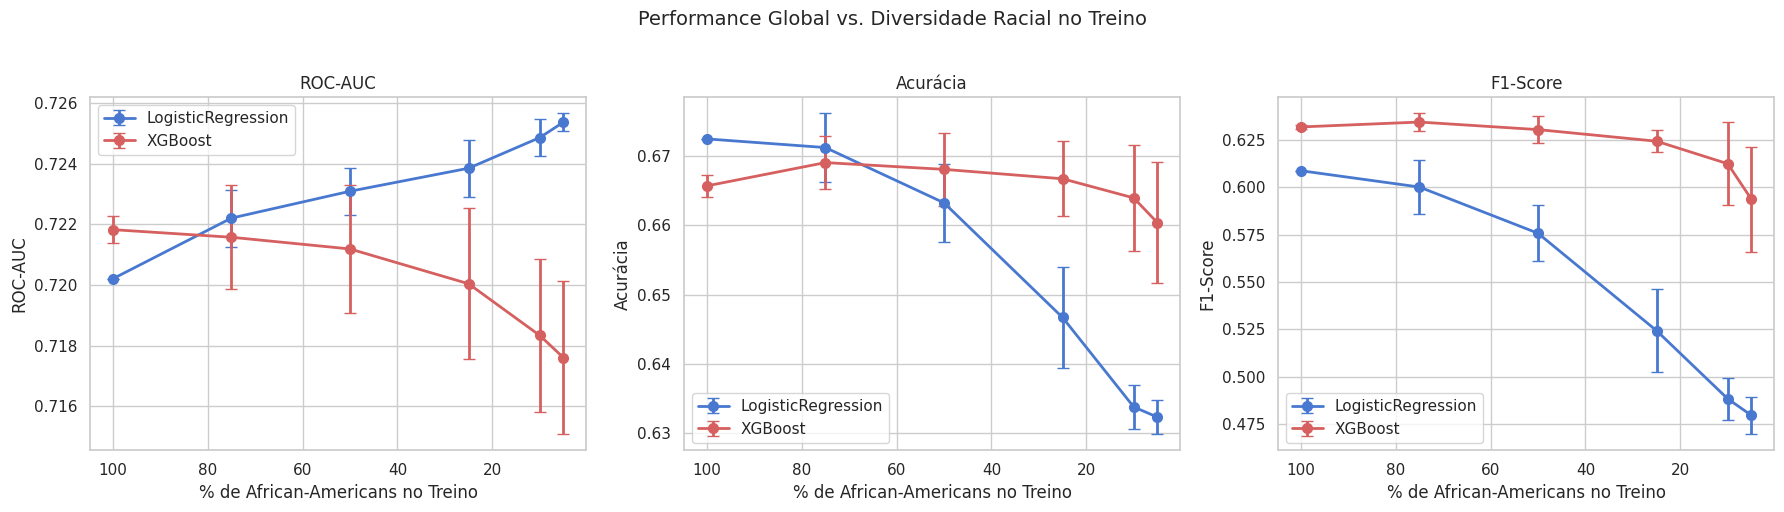

In [9]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 9 · PERFORMANCE GLOBAL POR NÍVEL
# ══════════════════════════════════════════════════════════════════
#
# Mostra como ROC-AUC, Acurácia e F1 evoluem com a redução da
# diversidade racial no treino.
#
# Esperado: estabilidade — o teto informacional do dataset permanece.
# Confirma que o subsampling NÃO degrada a capacidade preditiva
# global, isolando o efeito sobre o viés.
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_global = [
    ('roc_auc',  'ROC-AUC'),
    ('acuracia', 'Acurácia'),
    ('f1',       'F1-Score'),
]

models = ['LogisticRegression', 'XGBoost']
colors = {'LogisticRegression': '#4878CF', 'XGBoost': '#D65F5F'}

for ax, (metric, title) in zip(axes, metrics_global):
    for model in models:
        sub = df_summary[df_summary['modelo'] == model].sort_values('level')
        ax.errorbar(
            sub['level'] * 100,
            sub[f'{metric}_mean'],
            yerr=sub[f'{metric}_std'],
            marker='o', markersize=7, capsize=4,
            label=model, color=colors[model], linewidth=2
        )
    ax.set_xlabel('% de African-Americans no Treino')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()
    ax.invert_xaxis()  # 100% à esquerda, 5% à direita

plt.suptitle('Performance Global vs. Diversidade Racial no Treino',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/exp_performance_global.png', dpi=150, bbox_inches='tight')
plt.show()

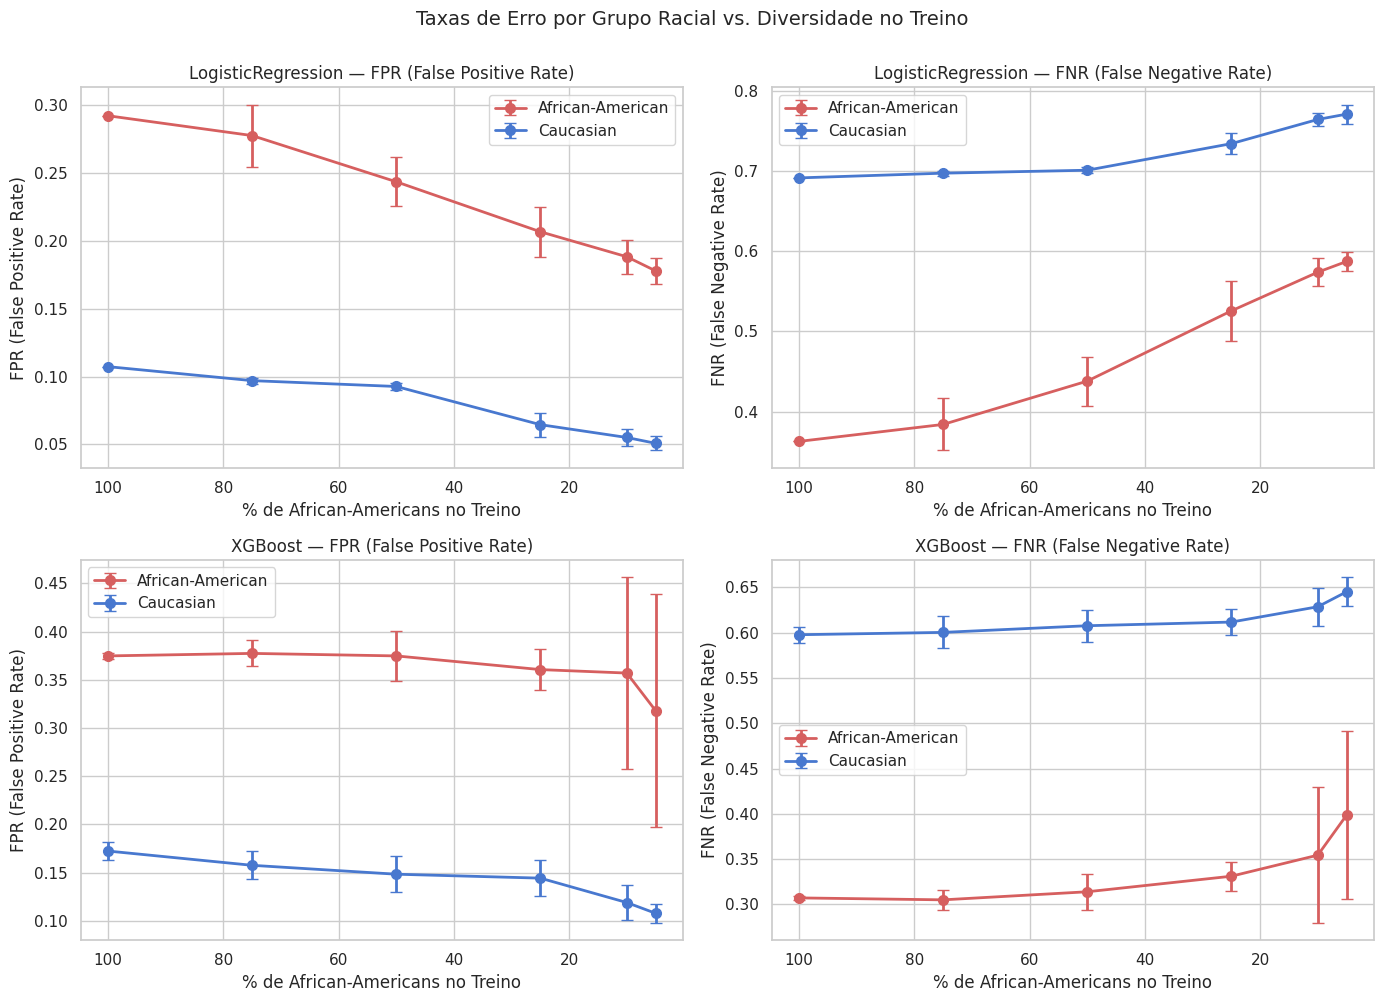

In [10]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 10 · FPR E FNR POR GRUPO RACIAL
# ══════════════════════════════════════════════════════════════════
#
# Painel 2x2 — uma linha por modelo, uma coluna por métrica
# (FPR e FNR). Cada plot mostra a evolução para AA e W.
#
# Achado esperado: no LR, AA tem FPR caindo drasticamente (modelo
# vira conservador para a minoria). No XGBoost, FPR de AA cai menos.
# Esse plot escala a mecânica do achado contraintuitivo.
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

groups   = [('aa', 'African-American', '#D65F5F'),
            ('w',  'Caucasian',         '#4878CF')]
metrics  = [('fpr', 'FPR (False Positive Rate)'),
            ('fnr', 'FNR (False Negative Rate)')]

for row, model in enumerate(models):
    sub = df_summary[df_summary['modelo'] == model].sort_values('level')

    for col, (metric_key, metric_title) in enumerate(metrics):
        ax = axes[row, col]
        for prefix, group_name, color in groups:
            ax.errorbar(
                sub['level'] * 100,
                sub[f'{prefix}_{metric_key}_mean'],
                yerr=sub[f'{prefix}_{metric_key}_std'],
                marker='o', markersize=7, capsize=4,
                label=group_name, color=color, linewidth=2
            )
        ax.set_xlabel('% de African-Americans no Treino')
        ax.set_ylabel(metric_title)
        ax.set_title(f'{model} — {metric_title}')
        ax.legend()
        ax.invert_xaxis()

plt.suptitle('Taxas de Erro por Grupo Racial vs. Diversidade no Treino',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('/content/exp_fpr_fnr.png', dpi=150, bbox_inches='tight')
plt.show()

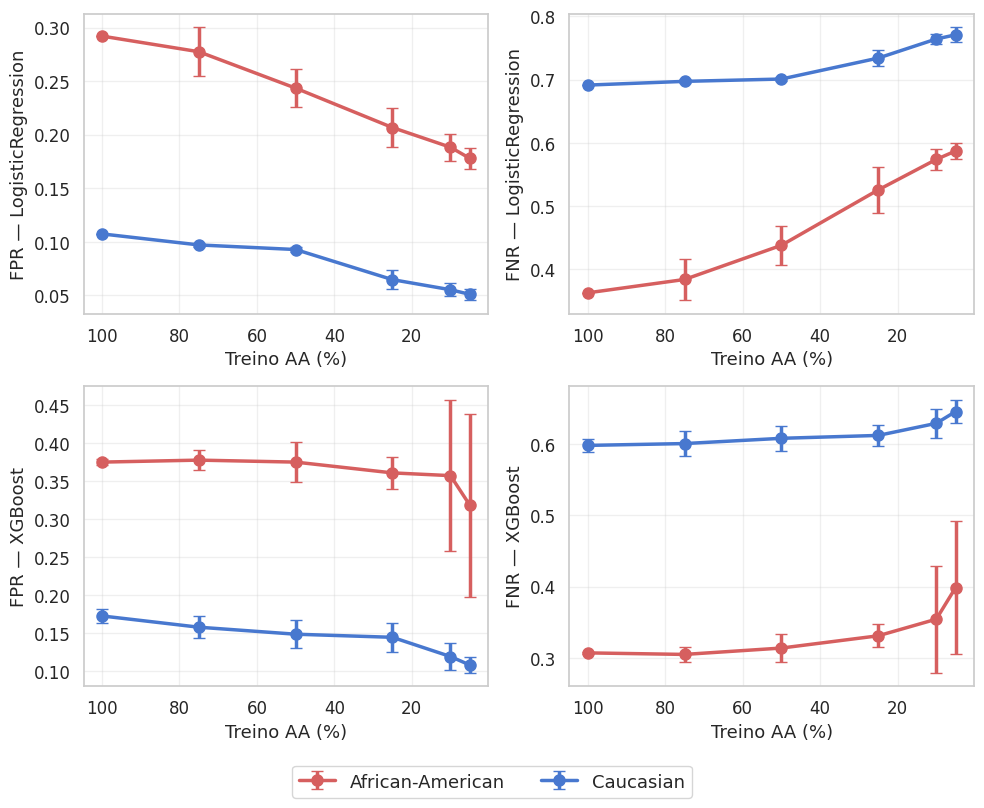

In [12]:
# ── FIGURA 1 PRINT — FPR e FNR por grupo racial ───────────────────

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

groups   = [('aa', 'African-American', '#D65F5F'),
            ('w',  'Caucasian',         '#4878CF')]
metrics  = [('fpr', 'FPR'), ('fnr', 'FNR')]

handles = []
labels  = []

for row, model in enumerate(models):
    sub = df_summary[df_summary['modelo'] == model].sort_values('level')
    for col, (metric_key, metric_label) in enumerate(metrics):
        ax = axes[row, col]
        for prefix, group_name, color in groups:
            line = ax.errorbar(
                sub['level'] * 100,
                sub[f'{prefix}_{metric_key}_mean'],
                yerr=sub[f'{prefix}_{metric_key}_std'],
                marker='o', markersize=8, capsize=4,
                label=group_name, color=color, linewidth=2.5
            )
            # Captura handles apenas uma vez para a legenda externa
            if row == 0 and col == 0:
                handles.append(line)
                labels.append(group_name)

        ax.set_xlabel('Treino AA (%)', fontsize=13)
        ax.set_ylabel(f'{metric_label} — {model}', fontsize=13)
        ax.tick_params(labelsize=12)
        ax.invert_xaxis()
        ax.grid(True, alpha=0.3)

# Legenda única abaixo dos subplots
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=13,
    frameon=True
)

plt.tight_layout(rect=[0, 0.04, 1, 1])  # reserva espaço inferior para a legenda
plt.savefig('/content/fig1_print.png', dpi=200, bbox_inches='tight')
plt.show()

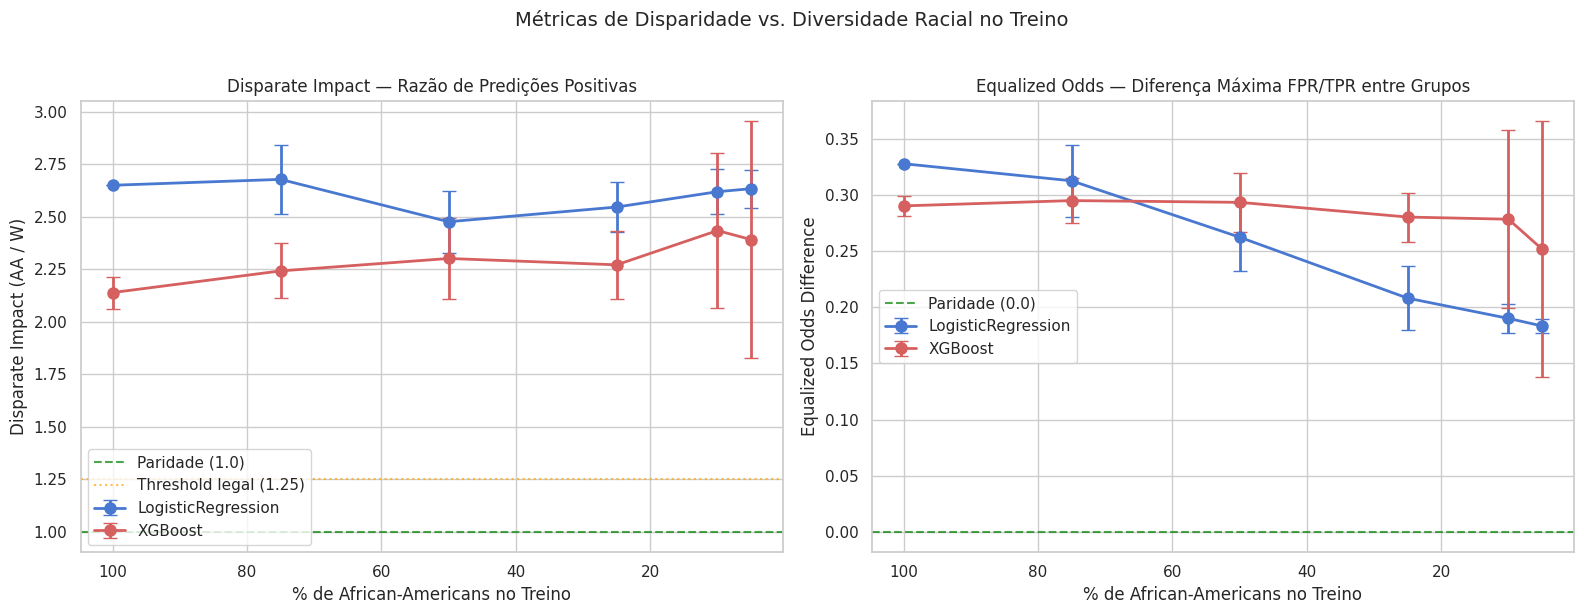

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 11 · MÉTRICAS DE DISPARIDADE — CORAÇÃO DO EXPERIMENTO
# ══════════════════════════════════════════════════════════════════
#
# Disparate Impact e Equalized Odds Difference são as métricas
# centrais do artigo. Elas medem DISPARIDADE entre grupos, não
# performance individual por grupo.
#
# Linhas de referência:
#   - Disparate Impact = 1.0 (paridade total) — linha verde
#   - Disparate Impact = 0.8 (threshold legal "regra dos 4/5")
#     — linha amarela. Acima de 1.25 (1/0.8) é o equivalente
#     simétrico para o grupo majoritário.
#
# LR e XGB divergem em comportamento conforme a diversidade cai.
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 11a. Disparate Impact
ax = axes[0]
for model in models:
    sub = df_summary[df_summary['modelo'] == model].sort_values('level')
    ax.errorbar(
        sub['level'] * 100,
        sub['disparate_impact_mean'],
        yerr=sub['disparate_impact_std'],
        marker='o', markersize=8, capsize=5,
        label=model, color=colors[model], linewidth=2
    )

ax.axhline(y=1.0, color='green', linestyle='--', linewidth=1.5,
           label='Paridade (1.0)', alpha=0.7)
ax.axhline(y=1.25, color='orange', linestyle=':', linewidth=1.5,
           label='Threshold legal (1.25)', alpha=0.7)
ax.set_xlabel('% de African-Americans no Treino')
ax.set_ylabel('Disparate Impact (AA / W)')
ax.set_title('Disparate Impact — Razão de Predições Positivas')
ax.legend()
ax.invert_xaxis()

# 11b. Equalized Odds Difference
ax = axes[1]
for model in models:
    sub = df_summary[df_summary['modelo'] == model].sort_values('level')
    ax.errorbar(
        sub['level'] * 100,
        sub['eq_odds_diff_mean'],
        yerr=sub['eq_odds_diff_std'],
        marker='o', markersize=8, capsize=5,
        label=model, color=colors[model], linewidth=2
    )

ax.axhline(y=0.0, color='green', linestyle='--', linewidth=1.5,
           label='Paridade (0.0)', alpha=0.7)
ax.set_xlabel('% de African-Americans no Treino')
ax.set_ylabel('Equalized Odds Difference')
ax.set_title('Equalized Odds — Diferença Máxima FPR/TPR entre Grupos')
ax.legend()
ax.invert_xaxis()

plt.suptitle('Métricas de Disparidade vs. Diversidade Racial no Treino',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/exp_disparidade.png', dpi=150, bbox_inches='tight')
plt.show()

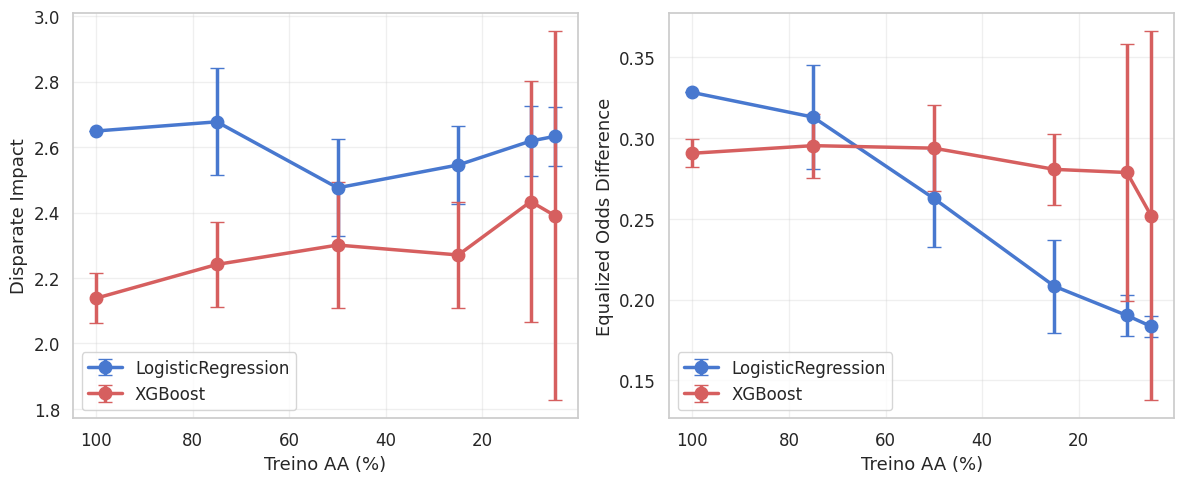

In [ ]:
# ── FIGURA 2 PRINT — Disparate Impact e Equalized Odds ────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Disparate Impact
ax = axes[0]
for model in models:
    sub = df_summary[df_summary['modelo'] == model].sort_values('level')
    ax.errorbar(
        sub['level'] * 100,
        sub['disparate_impact_mean'],
        yerr=sub['disparate_impact_std'],
        marker='o', markersize=9, capsize=5,
        label=model, color=colors[model], linewidth=2.5
    )
ax.set_xlabel('Treino AA (%)', fontsize=13)
ax.set_ylabel('Disparate Impact', fontsize=13)
ax.tick_params(labelsize=12)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

# Equalized Odds Difference
ax = axes[1]
for model in models:
    sub = df_summary[df_summary['modelo'] == model].sort_values('level')
    ax.errorbar(
        sub['level'] * 100,
        sub['eq_odds_diff_mean'],
        yerr=sub['eq_odds_diff_std'],
        marker='o', markersize=9, capsize=5,
        label=model, color=colors[model], linewidth=2.5
    )
ax.set_xlabel('Treino AA (%)', fontsize=13)
ax.set_ylabel('Equalized Odds Difference', fontsize=13)
ax.tick_params(labelsize=12)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('/content/fig2_print.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CÉLULA 12 · SÍNTESE FINAL DO EXPERIMENTO
# ══════════════════════════════════════════════════════════════════

key_levels = [1.00, 0.25, 0.05]
key_metrics = ['roc_auc_mean', 'aa_fpr_mean', 'w_fpr_mean',
               'disparate_impact_mean', 'eq_odds_diff_mean']

df_synthesis = (df_summary[df_summary['level'].isin(key_levels)]
                .sort_values(['modelo', 'level'], ascending=[True, False])
                [['modelo', 'level_pct'] + key_metrics]
                .reset_index(drop=True))

# Renomear colunas para legibilidade
df_synthesis.columns = ['Modelo', 'Diversidade',
                        'ROC-AUC', 'FPR (AA)', 'FPR (W)',
                        'Disp. Impact', 'Eq. Odds Diff']

print("=" * 90)
print("TABELA SÍNTESE — RESULTADOS DO EXPERIMENTO DE SUBSAMPLING")
print("=" * 90)
print(df_synthesis.round(4).to_string(index=False))
print("=" * 90)

# Cálculo das variações entre 100% e 5%
print("\n=== VARIAÇÃO 100% → 5% ===\n")
for model in models:
    full = df_summary[(df_summary['modelo'] == model) & (df_summary['level'] == 1.00)].iloc[0]
    low  = df_summary[(df_summary['modelo'] == model) & (df_summary['level'] == 0.05)].iloc[0]
    print(f"--- {model} ---")
    print(f"  ROC-AUC          : {full['roc_auc_mean']:.4f} → {low['roc_auc_mean']:.4f}  ({(low['roc_auc_mean']-full['roc_auc_mean']):+.4f})")
    print(f"  FPR (AA)         : {full['aa_fpr_mean']:.4f} → {low['aa_fpr_mean']:.4f}  ({(low['aa_fpr_mean']-full['aa_fpr_mean']):+.4f})")
    print(f"  FPR (W)          : {full['w_fpr_mean']:.4f} → {low['w_fpr_mean']:.4f}  ({(low['w_fpr_mean']-full['w_fpr_mean']):+.4f})")
    print(f"  Disparate Impact : {full['disparate_impact_mean']:.4f} → {low['disparate_impact_mean']:.4f}  ({(low['disparate_impact_mean']-full['disparate_impact_mean']):+.4f})")
    print(f"  Eq. Odds Diff    : {full['eq_odds_diff_mean']:.4f} → {low['eq_odds_diff_mean']:.4f}  ({(low['eq_odds_diff_mean']-full['eq_odds_diff_mean']):+.4f})")


TABELA SÍNTESE — RESULTADOS DO EXPERIMENTO DE SUBSAMPLING
            Modelo Diversidade  ROC-AUC  FPR (AA)  FPR (W)  Disp. Impact  Eq. Odds Diff
LogisticRegression      100pct   0.7202    0.2920   0.1073        2.6492         0.3281
LogisticRegression      025pct   0.7239    0.2066   0.0646        2.5455         0.2082
LogisticRegression      005pct   0.7254    0.1778   0.0509        2.6328         0.1835
           XGBoost      100pct   0.7218    0.3748   0.1723        2.1383         0.2905
           XGBoost      025pct   0.7200    0.3606   0.1442        2.2704         0.2806
           XGBoost      005pct   0.7176    0.3180   0.1077        2.3906         0.2520

=== VARIAÇÃO 100% → 5% (sinal indica direção) ===

--- LogisticRegression ---
  ROC-AUC          : 0.7202 → 0.7254  (+0.0052)
  FPR (AA)         : 0.2920 → 0.1778  (-0.1142)
  FPR (W)          : 0.1073 → 0.0509  (-0.0564)
  Disparate Impact : 2.6492 → 2.6328  (-0.0163)
  Eq. Odds Diff    : 0.3281 → 0.1835  (-0.1447)
--- XGB